# Data Leakage — A Gallery of Disasters

Leakage = test information bleeds into training, producing **fantastic CV scores that collapse in production**.
This notebook walks through three classic forms with code you can run.

| Type | Symptom | Fix |
|---|---|---|
| **Pre-processing leakage** | scaling / imputing / feature selection on full data | put it inside a `Pipeline` |
| **Target leakage**         | a feature *caused by* or *containing* the target | drop the feature; check timestamps |
| **Time leakage**           | random shuffles in temporal data | use `TimeSeriesSplit` |


## The picture — leakage = information crossing the train/test boundary

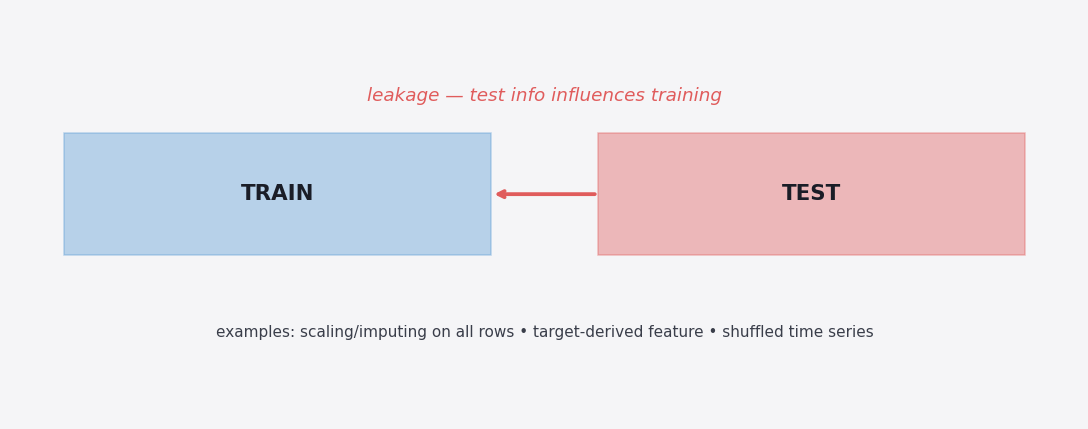

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(10, 4)); ax.axis('off')
ax.add_patch(Rectangle((0.05, 0.4), 0.4, 0.3, color=P[0], alpha=0.4))
ax.text(0.25, 0.55, 'TRAIN', ha='center', va='center', fontsize=14, weight='bold')
ax.add_patch(Rectangle((0.55, 0.4), 0.4, 0.3, color=P[1], alpha=0.4))
ax.text(0.75, 0.55, 'TEST', ha='center', va='center', fontsize=14, weight='bold')
ax.annotate('', xy=(0.45, 0.55), xytext=(0.55, 0.55),
            arrowprops=dict(arrowstyle='->', color=P[1], lw=2.5))
ax.text(0.5, 0.78, 'leakage — test info influences training',
        ha='center', fontsize=12, color=P[1], style='italic')
ax.text(0.5, 0.20, 'examples: scaling/imputing on all rows • target-derived feature • shuffled time series',
        ha='center', fontsize=10, color='#3a3e4a')
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, mean_squared_error


---
## 1. Pre-processing leakage — feature selection on full data

We have 1000 random features and 200 rows. None of them carry signal. A naive
"select top-K then cross-validate" picks features using the labels of points
that are *also* in the validation fold.


In [3]:
rng = np.random.RandomState(0)
n, p = 200, 1000
X = rng.randn(n, p)
y = rng.randint(0, 2, n)             # pure noise

# WRONG: select features using all of y, then CV
sel = SelectKBest(f_classif, k=20).fit(X, y)
X_pre = sel.transform(X)
wrong = cross_val_score(LogisticRegression(max_iter=2000), X_pre, y, cv=5,
                        scoring='roc_auc').mean()

# RIGHT: do selection inside the pipeline so each fold selects on its own train
pipe = Pipeline([('sel', SelectKBest(f_classif, k=20)),
                 ('clf', LogisticRegression(max_iter=2000))])
right = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc').mean()

print(f'leaky AUC  = {wrong:.3f}   (should be ~0.5 — random features cannot beat chance)')
print(f'honest AUC = {right:.3f}   (correct: ~0.5)')


leaky AUC  = 0.786   (should be ~0.5 — random features cannot beat chance)
honest AUC = 0.479   (correct: ~0.5)


---
## 2. Target leakage — a feature that contains the target

Imagine a `delinquent_30d` column in a credit-default model. It's measured *after* default,
so it perfectly predicts the target — until you deploy and don't have it.


In [4]:
rng = np.random.RandomState(0)
n = 1500
income       = rng.normal(50, 15, n)
credit_score = rng.normal(680, 70, n)
default      = ((income < 35) | (credit_score < 600)).astype(int)
# Engineered "after the fact": equals default + tiny noise
delinquent_30d = default + 0.05*rng.randn(n)

X_clean  = np.column_stack([income, credit_score])
X_leak   = np.column_stack([income, credit_score, delinquent_30d])

Xtr, Xte, ytr, yte = train_test_split(X_clean, default, random_state=0, stratify=default)
clean_auc = roc_auc_score(yte,
                          LogisticRegression(max_iter=2000).fit(Xtr, ytr)
                                              .predict_proba(Xte)[:,1])

Xtr, Xte, ytr, yte = train_test_split(X_leak, default, random_state=0, stratify=default)
leak_auc  = roc_auc_score(yte,
                          LogisticRegression(max_iter=2000).fit(Xtr, ytr)
                                              .predict_proba(Xte)[:,1])

print(f'honest features AUC = {clean_auc:.3f}')
print(f'with leaky feature  = {leak_auc:.3f}   <-- looks amazing, would crash in prod')


honest features AUC = 0.906
with leaky feature  = 1.000   <-- looks amazing, would crash in prod


---
## 3. Time leakage — shuffled splits on temporal data

Sales tomorrow is easy to predict if you've already seen sales the day after tomorrow.
KFold shuffles the time axis; **TimeSeriesSplit** does not.


shuffled CV MSE         = 0.541   (overly optimistic)
TimeSeriesSplit CV MSE  = 0.536   (the realistic estimate)


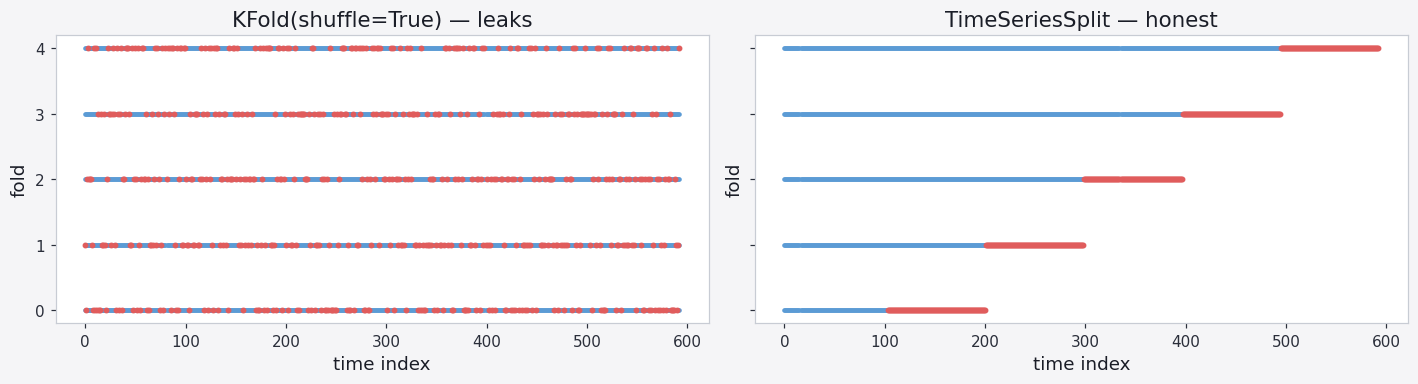

In [5]:
rng = np.random.RandomState(0)
n_days = 600
t = np.arange(n_days)
trend = 0.01*t
seasonal = 1.5*np.sin(2*np.pi*t/30)
y_ts = trend + seasonal + 0.3*rng.randn(n_days)

# Features = calendar + 7-lagged value
df_lag = np.column_stack([t, t % 30, np.roll(y_ts, 7)])
df_lag = df_lag[7:]
y_lag  = y_ts[7:]

cv_shuffle = KFold(n_splits=5, shuffle=True, random_state=0)
cv_time    = TimeSeriesSplit(n_splits=5)

mse_shuffle = -cross_val_score(LinearRegression(), df_lag, y_lag,
                               cv=cv_shuffle, scoring='neg_mean_squared_error').mean()
mse_time    = -cross_val_score(LinearRegression(), df_lag, y_lag,
                               cv=cv_time,    scoring='neg_mean_squared_error').mean()

print(f'shuffled CV MSE         = {mse_shuffle:.3f}   (overly optimistic)')
print(f'TimeSeriesSplit CV MSE  = {mse_time:.3f}   (the realistic estimate)')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
def draw(ax, splitter, title):
    for i, (tr, te) in enumerate(splitter.split(df_lag)):
        ax.scatter(tr, np.full_like(tr, i), color=PALETTE[0], s=4)
        ax.scatter(te, np.full_like(te, i), color=PALETTE[1], s=8)
    ax.set_title(title); ax.set_xlabel('time index'); ax.set_ylabel('fold')
    ax.set_yticks(range(5))
draw(axes[0], cv_shuffle, 'KFold(shuffle=True) — leaks')
draw(axes[1], cv_time,    'TimeSeriesSplit — honest')
plt.tight_layout(); plt.show()


---
## Defensive checklist

1. **Wrap every transform in a `Pipeline`** so it refits inside each CV fold.
2. **Audit each engineered feature** — could it have been measured *before* the label?
3. **For temporal data**, never `shuffle=True`. Use `TimeSeriesSplit` or a forward-chaining split.
4. **Sanity check**: an AUC > 0.99 or R² > 0.99 on real-world data is almost always leakage.
5. **Holdout a final test set** never touched until you ship.

> Rule of thumb: if results look too good, **assume leakage** and search for it before celebrating.
